# Principal Component Analysis (PCA) — Case Study

## Customer Fidelity Prediction at UrbanMart

---

## 1. Business Context

**UrbanMart** is an online retail company specializing in household and lifestyle products. The marketing analytics team collected behavioral data on **n = 120 customers** with three goals:

1. **Dimensionality reduction:** reduce 8 correlated variables into a smaller set of interpretable dimensions. No consider Fidelity (the response variable in a future machile learning task)
2. **Visualization:** project customers onto the principal component space to discover segments.

---

## 2. Variable Description

The dataset contains 8 predictor variables organized in three behavioral domains, plus one response variable.

### Spending Behavior

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `purchase_frequency` | Discrete | 1–20 | Number of purchases per month |
| `avg_order_value` | Continuous | 10–200 USD | Average dollar amount per order |
| `total_spent_year` | Continuous | 100–3,000 USD | Total expenditure in the past 12 months |

### Digital Engagement

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `website_visits_month` | Discrete | 1–60 | Number of website visits per month |
| `email_open_rate` | Continuous | 5–85 % | Percentage of marketing emails opened |
| `app_sessions_week` | Discrete | 0–20 | Number of mobile app sessions per week |

### Customer Satisfaction

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `support_satisfaction` | Ordinal | 1–10 | Self-reported satisfaction with customer support |
| `review_score` | Ordinal | 1.0–5.0 | Average product review score given by the customer |

### Response Variable

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `fidelity_score` | Continuous | 0–100 | Composite loyalty index combining retention probability, repurchase intent, and Net Promoter Score |

---

## 3. Methodology

### 3.1 Standardization

Since PCA is sensitive to variable scales, all 8 predictors are standardized before analysis:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}, \quad j = 1, \ldots, 8$$

### 3.2 Principal Component Analysis

PCA finds orthogonal linear combinations of the standardized variables that maximize variance. The $k$-th principal component is:

$$\text{PC}_k = a_{k1}\,z_1 + a_{k2}\,z_2 + \cdots + a_{k8}\,z_8$$

where $\mathbf{a}_k$ is the $k$-th eigenvector of the correlation matrix $\mathbf{R}$, and the eigenvalue $\lambda_k$ is the variance captured by $\text{PC}_k$. The proportion of total variance explained is:

$$\frac{\lambda_k}{\sum_{j=1}^{8} \lambda_j} = \frac{\lambda_k}{8}$$

### 3.3 From Loadings to Correlations

The raw loading $a_{kj}$ is the weight of variable $j$ in component $k$. To obtain the **correlation** between a variable and a component:

$$r(X_j,\, \text{PC}_k) = a_{kj} \times \sqrt{\lambda_k}$$

This rescales each loading by the standard deviation of its component, yielding a Pearson correlation on $[-1, +1]$.

---


In [ ]:
import pandas as pd
data = pd.read_excel('OnlineCompany.xlsx')
data.head()

,purchase_frequency,avg_order_value,total_spent_year,website_visits_month,email_open_rate,app_sessions_week,support_satisfaction,review_score,fidelity_score
0,7,64,1044,22,47,7,4.2,2.9,58
1,6,47,689,4,24,3,5.6,3.3,42
2,7,60,1111,24,52,8,6.8,3.9,72
3,10,86,1491,5,16,1,8.8,4.4,64
4,5,47,731,20,44,6,3.8,2.6,45


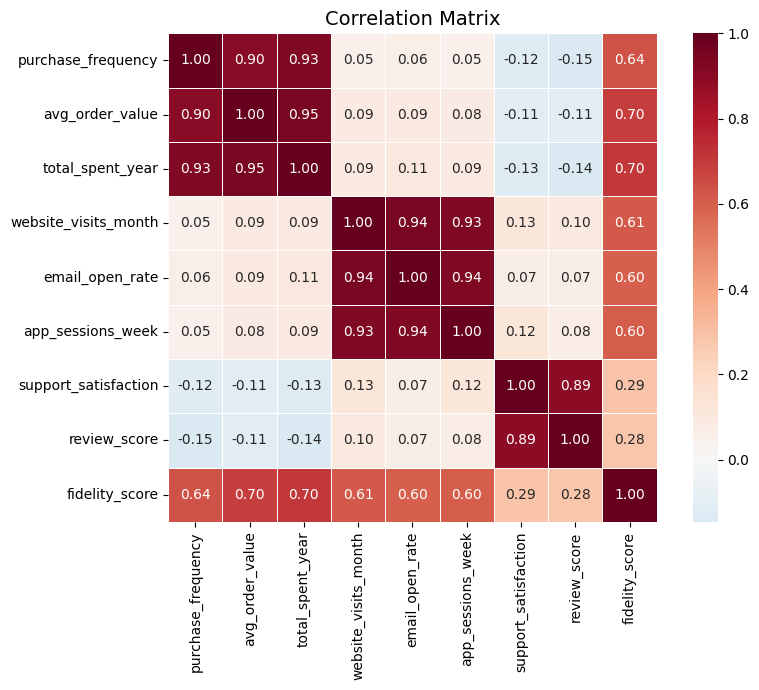

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()